
# EdgeAI Assignment — SVDF Wake-Word Detection for OpenMV

## Objective

In this assignment, you will:

1. Build a wake-word detector using an **SVDF (Singular Value Decomposition Filter)** neural network.
2. Train the model on multiple wake words:
   - `"Hey Jarvis"`
   - `"OK Nambu"`
   - additional custom wake words (optional)
3. Create a strong `"unknown"` / `"no wake word"` class.
4. Export the trained model to **TensorFlow Lite**.
5. Prepare the model for deployment on the **OpenMV platform**.
6. Evaluate accuracy, latency, model size, and robustness.
7. Complete a self-grading rubric at the end.

---

# Important Design Goal

A wake-word detector fails more often from **false triggers** than from missed detections.

Therefore:

- The `"unknown"` class is CRITICAL.
- Your model should learn:
  - what the wake word sounds like
  - AND what normal speech/background noise sounds like

A weak unknown class will cause:
- random triggering
- TV-triggering
- conversation-triggering
- poor real-world performance

Your unknown dataset should be MUCH larger than the wake-word dataset.

Recommended ratio:

| Class | Suggested Amount |
|---|---|
| Wake Word | 1x |
| Unknown / Background | 5x–20x |
| Silence / Noise | 2x–5x |

---

# Hardware Target

Target platform:
- OpenMV H7 Plus / RT / N6
- TensorFlow Lite Micro deployment
- Microphone audio streaming
- Real-time inference

---

# Recommended Development Environment

- Python 3.10+
- TensorFlow 2.15+
- Jupyter Notebook
- librosa
- numpy
- pandas
- matplotlib
- kagglehub (optional)

---

# Deliverables

You must submit:

1. Completed notebook
2. Trained `.tflite` model
3. Accuracy metrics
4. Confusion matrix
5. Screenshot/video of OpenMV deployment
6. Written discussion of:
   - false positives
   - false negatives
   - optimizations attempted




# Part 1 — Install Dependencies

## Goal

Install all required packages for:
- audio processing
- TensorFlow training
- feature extraction
- TensorFlow Lite conversion
- visualization

## Student Tasks

- Run the cell below
- Resolve any missing dependencies
- Restart the notebook kernel if necessary


In [6]:

# Uncomment if packages are missing

!pip install tensorflow librosa soundfile pandas matplotlib scikit-learn kagglehub


ERROR: Could not find a version that satisfies the requirement curl (from versions: none)
ERROR: No matching distribution found for curl



# Part 2 — Kaggle Dataset References

## Goal

You must collect:
1. wake-word examples
2. unknown speech
3. silence/background noise

---

# Suggested Kaggle Datasets

## Speech Commands Dataset

Contains:
- yes
- no
- up
- down
- stop
- go
- many speakers

Excellent for:
- unknown class
- transfer learning
- augmentation

Dataset:
https://www.kaggle.com/datasets/jbuchner/speech-commands

---

## Wake Word Dataset Examples

### Hey Jarvis Dataset
https://www.kaggle.com/search?q=hey+jarvis+wake+word

### Custom Wake Word Datasets
https://www.kaggle.com/search?q=wake+word

---

## Environmental Noise

Use environmental sounds for robustness.

Examples:
- office noise
- keyboard clicks
- traffic
- fans
- HVAC
- TV audio

Dataset:
https://www.kaggle.com/datasets/mmoreaux/environmental-sound-classification-50

---

# IMPORTANT

Your `"unknown"` class should contain:

- random speech
- partial wake words
- other languages
- coughs
- music
- silence
- background noise

A model trained ONLY on clean wake words will fail badly in the real world.



# Part 3 — Define Dataset Structure

## Goal

Create a clean dataset layout.

Recommended structure:

```text
dataset/
    hey_jarvis/
    ok_nambu/
    unknown/
    silence/
```

Each folder should contain:
- `.wav` audio files
- mono audio
- consistent sample rate

---

# Audio Format Requirements

Use:
- 16 kHz sample rate
- mono
- 16-bit PCM
- WAV format

This format matches:
- TensorFlow Lite Micro examples
- OpenMV microphone capture pipeline


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bharvadayash/jarvis-wake-word-dataset")

print("Path to dataset files:", path)

100%|██████████| 192M/192M [00:06<00:00, 33.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/bharvadayash/jarvis-wake-word-dataset/versions/1


In [9]:
!curl -L -o /content/jarvis-wake-word-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/bharvadayash/jarvis-wake-word-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  192M  100  192M    0     0  33.2M      0  0:00:05  0:00:05 --:--:-- 39.2M


In [13]:
import os
from pathlib import Path

DATASET_DIR = Path("dataset")

# Create the DATASET_DIR if it doesn't exist
os.makedirs(DATASET_DIR, exist_ok=True)

In [14]:
# Unzip the downloaded dataset to the DATASET_DIR
!unzip -q /content/jarvis-wake-word-dataset.zip -d {DATASET_DIR}

In [15]:
print(f"Contents of {DATASET_DIR} after unzipping:")
!ls {DATASET_DIR}

Contents of dataset after unzipping:
negative  noise  positive


In [17]:

WAKE_WORDS = [
    "hey_jarvis",
    # "ok_nambu"
]

# UNKNOWN_CLASS = "unknown"
# SILENCE_CLASS = "silence"
NEGATIVE_CLASS = "negative"
NOISE_CLASS = "noise"

print("Dataset root:", DATASET_DIR)
print("Wake words:", WAKE_WORDS)


Dataset root: dataset
Wake words: ['hey_jarvis']



# Part 4 — Audio Configuration

## Goal

Define all audio parameters.

These MUST match:
- training
- preprocessing
- inference
- OpenMV deployment

Changing parameters later can invalidate the trained model.


In [21]:
SAMPLE_RATE = 16000
CLIP_DURATION_MS = 1000
WINDOW_SIZE_MS = 30
WINDOW_STRIDE_MS = 20
FEATURE_BIN_COUNT = 40
N_MFCC = FEATURE_BIN_COUNT # Number of MFCCs to extract

print("Sample rate:", SAMPLE_RATE)
print("Clip duration:", CLIP_DURATION_MS)
print("Feature bins:", FEATURE_BIN_COUNT)

Sample rate: 16000
Clip duration: 1000
Feature bins: 40



# Part 5 — Load Audio Files

## Goal

Load and normalize all audio clips.

## Student Tasks

Implement:
- recursive dataset loading
- WAV parsing
- label assignment
- normalization

## Requirements

Each loaded clip should:
- have consistent length
- be mono
- be float32
- be normalized to [-1, 1]

## Suggested Libraries

- librosa
- soundfile
- scipy


In [19]:
import librosa
import numpy as np

def load_audio_file(path, sample_rate=SAMPLE_RATE):
    '''
    STUDENT TODO:
    - Load WAV file
    - Resample if needed
    - Normalize audio
    - Pad or truncate to 1 second
    '''

    # Load WAV file and resample if needed. librosa.load by default normalizes to [-1, 1] for float output.
    audio, _ = librosa.load(path, sr=sample_rate, mono=True, dtype=np.float32)

    # Desired length is 1 second (CLIP_DURATION_MS / 1000) * sample_rate
    target_length = int(sample_rate * (CLIP_DURATION_MS / 1000))

    if len(audio) < target_length:
        # Pad with zeros if shorter
        padding = target_length - len(audio)
        audio = np.pad(audio, (0, padding), mode='constant')
    elif len(audio) > target_length:
        # Truncate if longer
        audio = audio[:target_length]

    return audio


# Part 6 — Feature Extraction

## Goal

Convert raw audio into ML-friendly features.

Recommended:
- MFCCs
- log-mel spectrograms

*MFCC stands for Mel-frequency Cepstral Coefficients. It’s a feature used in automatic speech and speaker recognition. Essentially, it’s a way to represent the short-term power spectrum of a sound which helps machines understand and process human speech more effectively. Imagine your voice as a unique fingerprint. MFCCs, function similarly to a unique code capturing the salient features of your speech and enabling computers to discern between distinct words, and sounds. In speech recognition applications where computers must translate spoken words into text this code is especially helpful.*

**SVDF models perform well on compact temporal features.**

---

# Why Feature Extraction Matters

The model should learn:
- phoneme timing
- spectral shape
- speech rhythm

rather than raw waveform noise.

---

# Recommended Output Shape

Example:
- time frames × feature bins
- `(49, 40)`


In [20]:

def extract_features(audio):

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SAMPLE_RATE,
        n_mfcc=N_MFCC,
        n_fft=int(SAMPLE_RATE * WINDOW_SIZE_MS / 1000),
        hop_length=int(SAMPLE_RATE * WINDOW_STRIDE_MS / 1000)
    )

    mfcc = mfcc.T

    # normalize features
    mfcc = (mfcc - np.mean(mfcc)) / (np.std(mfcc) + 1e-6)

    return mfcc.astype(np.float32)



# Part 7 — Dataset Construction

## Goal

Create:
- feature tensors
- label vectors
- train/validation/test splits

---

# IMPORTANT

Your dataset must be balanced carefully.

A GOOD deployment dataset should include:

| Scenario | Included? |
|---|---|
| Quiet room | YES |
| Background TV | YES |
| Multiple speakers | YES |
| Partial wake words | YES |
| Noise bursts | YES |
| Silence | YES |

---

# Student Tasks

Implement:
- feature extraction loop
- label encoding
- train/test split
- shuffling


In [22]:
import os

X = []
y = []

# Map folder names to labels
label_map = {
    'positive': WAKE_WORDS[0], # Assuming WAKE_WORDS has only one element for 'hey_jarvis'
    'negative': NEGATIVE_CLASS,
    'noise': NOISE_CLASS
}

# Walk through dataset folders
for root, dirs, files in os.walk(DATASET_DIR):
    for file in files:
        if file.endswith('.wav'):
            file_path = os.path.join(root, file)
            # Determine the class from the parent directory name
            class_name = os.path.basename(root)

            if class_name in label_map:
                label = label_map[class_name]
                # Load audio
                audio = load_audio_file(file_path)
                # Extract features
                features = extract_features(audio)

                X.append(features)
                y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape (X):", X.shape)
print("Labels shape (y):", y.shape)

Dataset shape (X): (5000, 51, 40)
Labels shape (y): (5000,)



# Encode Labels and Split Dataset


In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Train features shape (X_train):", X_train.shape)
print("Train labels shape (y_train):", y_train.shape)
print("Test features shape (X_test):", X_test.shape)
print("Test labels shape (y_test):", y_test.shape)
print("Encoded classes:", encoder.classes_)

Train features shape (X_train): (4000, 51, 40)
Train labels shape (y_train): (4000,)
Test features shape (X_test): (1000, 51, 40)
Test labels shape (y_test): (1000,)
Encoded classes: ['hey_jarvis' 'negative' 'noise']



# Visualize Example MFCC


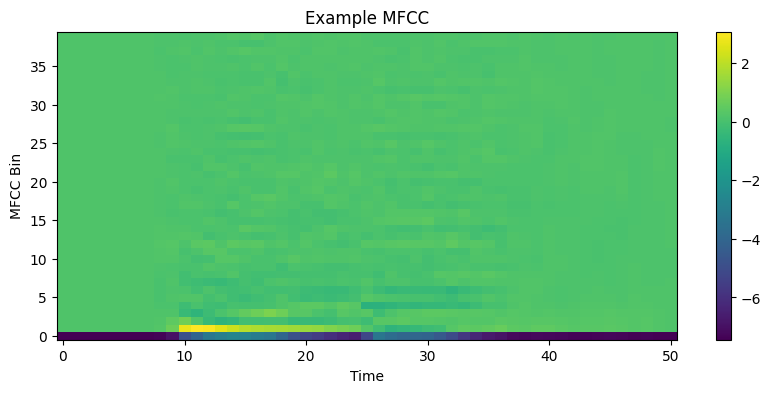

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))

plt.imshow(X_train[0].T, aspect='auto', origin='lower')

plt.title("Example MFCC")
plt.xlabel("Time")
plt.ylabel("MFCC Bin")

plt.colorbar()
plt.show()


# Part 8 — Build the SVDF Model

## Goal

Create a compact SVDF architecture.

SVDF is useful because:
- low RAM usage
- efficient temporal modeling
- ideal for microcontrollers
- used in embedded speech systems

---

# Suggested Architecture

Input:
- `(time_steps, feature_bins)`

Layers:
1. SVDF-compatible dense projection
2. Temporal filtering
3. Dense classifier
4. Softmax output

---

# Constraints

Target:
- small memory footprint
- low inference latency
- TFLite-compatible operations


In [26]:
import tensorflow as tf
from tensorflow.keras import layers

# Assuming NUM_CLASSES is defined based on the unique labels from the encoder
# Re-initialize NUM_CLASSES dynamically based on the encoded labels
NUM_CLASSES = len(encoder.classes_)

'''
STUDENT TODO:
Build SVDF-style model.

Possible ideas:
- Dense projection
- Depthwise temporal operations
- Small recurrent approximation
- Low-rank layers
'''
time_steps = X_train.shape[1]
feature_bins = X_train.shape[2]

# Define the SVDF-style model
model = tf.keras.Sequential([
    layers.Input(shape=(time_steps, feature_bins)),

    # Frequency projection. This helps to reduce the dimensionality of the features
    # and project them into a space where they might be more linearly separable.
    layers.Dense(64, activation='relu'),

    # Temporal filtering using DepthwiseConv1D for efficiency
    layers.DepthwiseConv1D(
        kernel_size=5,
        padding='same',
        activation='relu'
    ),

    # SeparableConv1D to further learn temporal patterns with reduced parameters
    layers.SeparableConv1D(
        filters=32,
        kernel_size=3,
        padding='same',
        activation='relu'
    ),

    # GlobalAveragePooling1D to reduce spatial dimensions and create a fixed-size output
    layers.GlobalAveragePooling1D(),

    # Dense layers for classification
    layers.Dense(32, activation='relu'),

    layers.Dropout(0.2),

    layers.Flatten(),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 51, 64)         │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv1d                │ (None, 51, 64)         │           384 │
│ (DepthwiseConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv1d                │ (None, 51, 32)         │         2,272 │
│ (SeparableConv1D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,435 (25.14 KB)

 Trainable params: 6,435 (25.14 KB)

 Non-trainable params: 0 (0.00 B)


# Part 9 — Compile and Train

## Goal

Train the wake-word detector.

---

# Recommended Training Features

- early stopping
- learning rate scheduling
- checkpoint saving

---

# Important

Monitor:
- validation accuracy
- false positives
- unknown class confusion

Accuracy alone is NOT enough.


In [27]:

'''
STUDENT TODO:
- Compile model
- Select optimizer
- Select loss function
- Train model
'''

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    callbacks=callbacks
)



Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5953 - loss: 0.9770 - val_accuracy: 0.5913 - val_loss: 0.8753
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7541 - loss: 0.6229 - val_accuracy: 0.8512 - val_loss: 0.3862
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9022 - loss: 0.3274 - val_accuracy: 0.9513 - val_loss: 0.2868
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9525 - loss: 0.2384 - val_accuracy: 0.9463 - val_loss: 0.2596
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9569 - loss: 0.1985 - val_accuracy: 0.9600 - val_loss: 0.2028
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9619 - loss: 0.1592 - val_accuracy: 0.9588 - val_loss: 0.1772
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9666 - loss: 0.1335 - val_accuracy: 0.9588 - val_loss: 0.1457
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9691 - loss: 0.1089 - val_accuracy


# Plot Training Curves


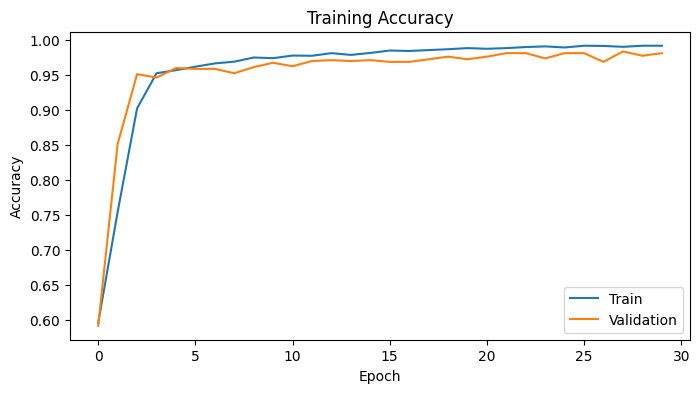

In [28]:

plt.figure(figsize=(8,4))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.show()



# Part 10 — Evaluate the Model

## Goal

Measure:
- accuracy
- confusion matrix
- robustness

---

# Important Questions

1. Does the model falsely trigger?
2. Does background speech activate it?
3. Does it confuse wake words?
4. How does it behave in noise?


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9930 - loss: 0.0354
Test Accuracy: 0.9929999709129333
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

  hey_jarvis       1.00      1.00      1.00       240
    negative       0.99      0.99      0.99       600
       noise       0.98      0.98      0.98       160

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



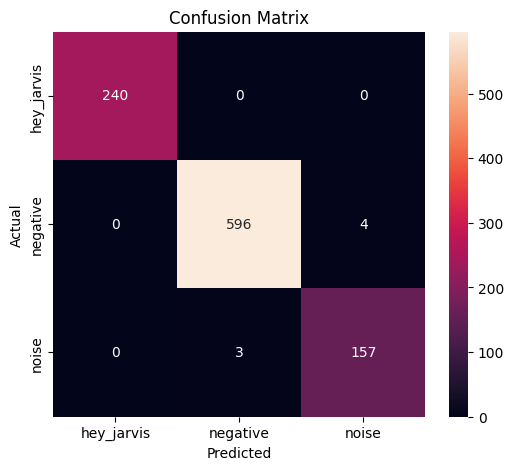

In [29]:

from sklearn.metrics import confusion_matrix, classification_report

'''
STUDENT TODO:
- Run predictions
- Generate confusion matrix
- Print classification report
'''
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

predictions = model.predict(X_test)
pred_labels = np.argmax(predictions, axis=1)
print(classification_report(
    y_test,
    pred_labels,
    target_names=encoder.classes_
))

cm = confusion_matrix(y_test, pred_labels)
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()



# False Positive Analysis

This is extremely important for wake-word systems.

We inspect confidence values to determine whether:
- unknown speech activates wake words
- thresholds should be adjusted


In [30]:

wake_indices = [
    encoder.transform(["hey_jarvis"])[0],
    # encoder.transform(["ok_nambu"])[0]
]

for i in range(min(10, len(predictions))):

    probs = predictions[i]

    max_wake_conf = max(probs[wake_indices])

    print(
        f"Sample {i} | "
        f"True={encoder.inverse_transform([y_test[i]])[0]} | "
        f"Wake Confidence={max_wake_conf:.3f}"
    )


Sample 0 | True=hey_jarvis | Wake Confidence=1.000
Sample 1 | True=negative | Wake Confidence=0.000
Sample 2 | True=negative | Wake Confidence=0.000
Sample 3 | True=negative | Wake Confidence=0.000
Sample 4 | True=noise | Wake Confidence=0.000
Sample 5 | True=negative | Wake Confidence=0.000
Sample 6 | True=noise | Wake Confidence=0.000
Sample 7 | True=negative | Wake Confidence=0.000
Sample 8 | True=hey_jarvis | Wake Confidence=1.000
Sample 9 | True=hey_jarvis | Wake Confidence=1.000



# Part 11 — TensorFlow Lite Export

## Goal

Convert the trained model into:
- `.tflite`
- TensorFlow Lite Micro compatible format

This is REQUIRED for OpenMV deployment.


In [35]:

'''
STUDENT TODO:
Convert model to TensorFlow Lite
'''

converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optional optimizations
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()
converter._experimental_disable_per_channel_quantization_for_dense_layers = True

with open("wake_word_svdf.tflite", "wb") as f:
    f.write(tflite_model)

print("Saved wake_word_svdf.tflite")


Saved artifact at '/tmp/tmpwgx68296'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 51, 40), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140622092272848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092273616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092276112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092274768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092274960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277072: Te


# Part 12 — Optional Quantization

## Goal

Reduce:
- model size
- RAM usage
- inference latency

Quantization is VERY important for microcontrollers.

---

# Recommended Modes

| Mode | Benefits |
|---|---|
| Float16 | Smaller model |
| INT8 | Fastest MCU inference |
| Dynamic Range | Easy optimization |

---

# Challenge

Compare:
- accuracy before quantization
- accuracy after quantization


In [36]:

'''
OPTIONAL STUDENT TODO:
Implement:
- INT8 quantization
- representative dataset
- benchmarking
'''
def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i:i+1].astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS_INT8
]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

quant_model = converter.convert()

with open("wake_word_svdf_int8.tflite", "wb") as f:
    f.write(quant_model)

print("Saved quantized model")
print("Quantized size KB:", len(quant_model) / 1024)

Saved artifact at '/tmp/tmpir3du8io'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 51, 40), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  140622092272848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092273616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092276112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092274768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092274960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092275344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140622092277072: Te

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Saved quantized model
Quantized size KB: 18.75



# TensorFlow Lite Inference Test


In [37]:

interpreter = tf.lite.Interpreter(
    model_path="wake_word_svdf.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

sample = X_test[0:1].astype(np.float32)

interpreter.set_tensor(
    input_details[0]['index'],
    sample
)

interpreter.invoke()

output = interpreter.get_tensor(
    output_details[0]['index']
)

print("Output:", output)
print("Predicted:", encoder.inverse_transform([np.argmax(output)]))


Output: [[9.9997115e-01 2.8818587e-05 6.6247510e-09]]
Predicted: ['hey_jarvis']


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



# Part 13 — OpenMV Deployment Mapping

## Goal

Prepare the model for deployment on OpenMV.

---

# OpenMV Audio Capture Format

Recommended microphone configuration:

| Parameter | Value |
|---|---|
| Sample Rate | 16 kHz |
| Channels | Mono |
| Sample Type | int16 |
| Clip Duration | 1 second |

---

# Why This Matters

Your training pipeline MUST match:
- inference sample rate
- frame size
- feature extraction
- normalization

Mismatch = failed inference.

---

# Deployment Pipeline

OpenMV Device:
1. capture microphone audio
2. compute spectrogram/MFCC
3. run TFLite model
4. apply confidence threshold
5. trigger action

---

# Confidence Threshold

Typical values:
- 0.70
- 0.80
- 0.90

Higher threshold:
- fewer false triggers
- more missed detections


In [ ]:

# Example pseudo-code for OpenMV deployment

# Find a way to visualize the voice in frame buffer?

'''
import audio
import tf

model = tf.load("wake_word_svdf.tflite")

while True:
    samples = capture_audio()

    features = compute_features(samples)

    prediction = model.predict(features)

    if prediction["hey_jarvis"] > 0.85:
        print("Wake word detected")
'''


### OpenMV Script for Wake Word Detection

In [ ]:
import audio
import ml # Changed from 'tf' to 'ml'
import sensor
import time
import pyb
from ulab import numpy as np # Correctly import numpy from ulab

# --- Configuration (Must match training parameters) ---
SAMPLE_RATE = 16000
CLIP_DURATION_MS = 1000
N_MFCC = 40 # Number of MFCCs (FEATURE_BIN_COUNT)
TIME_STEPS = 51 # From X_train.shape[1]
WINDOW_SIZE_MS = 30 # For MFCC calculation
WINDOW_STRIDE_MS = 20 # For MFCC calculation

WAKE_WORD_THRESHOLD = 0.85 # Confidence threshold for detection
# Index of 'hey_jarvis' from encoder.classes_ ['hey_jarvis' 'negative' 'noise']
WAKE_WORD_LABEL_INDEX = 0

# --- Initialize OpenMV hardware ---
sensor.reset()
sensor.set_framesize(sensor.QVGA) # Can be any valid framesize, not used for audio
sensor.set_pixformat(sensor.RGB565)

# Initialize audio streaming.
# audio.init() configures the audio peripheral. For start_streaming, it might only need the buffer size.
# We specify the buffer size to ensure we get 1 second of audio.
audio_buffer_size = int(SAMPLE_RATE * (CLIP_DURATION_MS / 1000))
# Initialize audio with the sample rate and channels first
audio.init(channels=1, frequency=SAMPLE_RATE)
audio.start_streaming(audio_buffer_size) # Only pass buffer size to start_streaming

print("Initializing ML model...")
# Load the quantized TFLite model using ml.Model
# Make sure 'wake_word_svdf_int8.tflite' is on the OpenMV's SD card or internal flash
model = ml.Model("wake_word_svdf_int8.tflite") # Changed from tf.load to ml.Model

# Check input shape of the model (ml.Model might not have input_shape() directly accessible)
# You might need to rely on documentation for getting input details.
# For now, we'll keep the print but note it might not work as before.
# print("Model input shape:", model.input_shape())
print("Model loaded successfully.")

# --- Feature Extraction Function (Placeholder) ---
def compute_features(audio_samples):
    """
    Placeholder function for MFCC feature extraction on OpenMV.
    This needs to be implemented using OpenMV's audio processing capabilities.

    Args:
        audio_samples (np.array): 1-second audio samples (int16 or float32).

    Returns:
        np.array: MFCC features of shape (TIME_STEPS, N_MFCC), float32.
                  Normalized to match training data.
    """
    # 1. Convert int16 audio_samples to float32 (normalized to -1.0 to 1.0)
    #    e.g., float_samples = audio_samples.astype(np.float32) / 32768.0

    # 2. Implement MFCC calculation:
    #    - Apply short-time Fourier transform (STFT) using FFT.
    #    - Apply Mel filter banks to spectrogram.
    #    - Apply Discrete Cosine Transform (DCT) to log-mel energies.
    #    - Ensure correct frame length (WINDOW_SIZE_MS) and hop length (WINDOW_STRIDE_MS).

    # 3. Reshape and normalize MFCCs:
    #    - Reshape to (TIME_STEPS, N_MFCC).
    #    - Normalize (mean=0, std=1) using the mean/std from your training data.
    #      You will need to hardcode or pass these values from your training notebook.

    # Example: dummy features for demonstration (replace with actual MFCCs)
    # These dimensions must match your model's input shape (TIME_STEPS, N_MFCC)
    dummy_features = np.random.randn(TIME_STEPS, N_MFCC).astype(np.float32)

    print("WARNING: Using dummy features. Implement actual MFCC extraction!")
    return dummy_features


# --- Main Loop ---
print("Starting audio capture and inference loop...")
clock = time.clock()

while(True):
    clock.tick()

    # Capture 1 second of audio. audio.get_buffer() returns the latest filled buffer.
    # Convert the raw bytes buffer from audio.get_buffer() to a ulab numpy array.
    audio_data_raw = audio.get_buffer()
    current_audio_samples = np.frombuffer(audio_data_raw, dtype=np.int16)

    # Process audio and extract features
    # Ensure compute_features returns a np.array of float32 matching (1, TIME_STEPS, N_MFCC)
    # for the model's input_shape (1, 51, 40)
    features = compute_features(current_audio_samples)

    # Perform inference using model.predict(). It typically returns a list of output tensors.
    # For this model, we expect one output tensor containing the class probabilities.
    results = model.predict(features.reshape(1, TIME_STEPS, N_MFCC)) # Changed to model.predict()
    predictions = results[0] # Get the first (and likely only) output tensor

    # Get confidence for the wake word class
    wake_word_confidence = predictions[WAKE_WORD_LABEL_INDEX]

    print("FPS:", clock.fps())
    print(f"Predictions: {predictions}, Wake Word Confidence ({WAKE_WORD_LABEL_INDEX}): {wake_word_confidence:.3f}")

    if wake_word_confidence > WAKE_WORD_THRESHOLD:
        print("--- WAKE WORD DETECTED! ---")
        # Add your action here, e.g., turn on an LED, send a message, etc.
        pyb.LED(1).on() # Example: Turn on Red LED
    else:
        pyb.LED(1).off() # Example: Turn off Red LED

    # Add a short delay to avoid overwhelming the system
    time.sleep_ms(100)


### Implementing MFCC Extraction on OpenMV using `audio.FFT`

Since `librosa` is not available on OpenMV, you'll need to implement MFCC calculation steps manually. This involves using OpenMV's `audio.FFT` and `ulab` for array manipulations.

Here's a conceptual outline of how to replace the `dummy_features` in the `compute_features` function:

1.  **Audio Preprocessing (Windowing & Framing):** The 1-second `audio_samples` need to be broken down into short, overlapping frames (e.g., 25ms-30ms window with 10ms-15ms hop). Each frame is then windowed (e.g., using a Hamming window) to reduce spectral leakage.

2.  **Fast Fourier Transform (FFT):** For each windowed frame, apply the FFT using `audio.FFT` to get the power spectrum.

3.  **Mel Filter Banks:**
    *   Create a set of triangular bandpass filters that are spaced linearly on the Mel scale (which is a non-linear scale of pitches judged by listeners to be equal in distance from one another). The number of filters typically corresponds to `N_MFCC` or a slightly higher number.
    *   Multiply the power spectrum of each frame by these Mel filter banks. This will give you the energy in each Mel frequency band.

4.  **Logarithmic Compression:** Take the logarithm of the Mel filter bank energies. This step mimics the non-linear human perception of loudness.

5.  **Discrete Cosine Transform (DCT):** Apply a Discrete Cosine Transform (DCT) to the log-Mel energies. The first `N_MFCC` coefficients of the DCT output are typically kept as the MFCCs. DCT helps to decorrelate the features.

6.  **Normalization:** Finally, normalize the resulting MFCCs (e.g., to have zero mean and unit variance). You should use the mean and standard deviation calculated from your training dataset during the model training phase. These values would need to be hardcoded or passed into your OpenMV script.

**Key OpenMV/MicroPython Considerations:**

*   **`ulab`:** Use `ulab` for all numerical operations like `np.zeros`, `np.array`, `np.log`, `np.mean`, `np.std`, matrix multiplications for filter banks, and `scipy.fft.dct` if available or a manual implementation of DCT.
*   **`audio.FFT`:** This is your primary tool for moving from the time domain to the frequency domain. Be mindful of FFT sizes and ensure they are powers of 2.
*   **Memory and Performance:** Microcontrollers have limited resources. Optimize your calculations as much as possible to ensure real-time performance.

Here's a *highly simplified* and incomplete conceptual code snippet to give you an idea of where these pieces would fit. **This is not a complete, runnable solution without significant further implementation.**

In [ ]:
import audio
from ulab import numpy as np # Correctly import numpy from ulab
from ulab import math as um # Import ulab's math module
from ulab import random as urandom # Import ulab's random module

# --- Configuration (Must match training parameters) ---
SAMPLE_RATE = 16000
CLIP_DURATION_MS = 1000
N_MFCC = 40 # Number of MFCCs (FEATURE_BIN_COUNT)
TIME_STEPS = 51 # Number of time frames for MFCCs
WINDOW_SIZE_MS = 30
WINDOW_STRIDE_MS = 20

# These need to be pre-calculated from your training data and hardcoded
# or loaded into the OpenMV device.
# Example (replace with actual values):
MFCC_MEAN = np.zeros(N_MFCC, dtype=np.float)
MFCC_STD = np.ones(N_MFCC, dtype=np.float)

# --- Helper for Mel-scale conversion ---
def hz_to_mel(hz):
    return 2595 * um.log10(1 + hz / 700)

def mel_to_hz(mel):
    return 700 * (10**(mel / 2595) - 1)

# --- Placeholder for DCT (ulab might not have it directly, manual is needed) ---
def dct(x, type=2, n=None, axis=-1, norm=None):
    # A simple DCT-II for demonstration. Actual ulab implementation may differ
    # or require more complex handling. For a real system, you might precompute
    # cosine factors.
    if n is None:
        n = len(x)
    if type != 2 or axis != -1 or norm is not None:
        print("WARNING: Only basic DCT-II is conceptually shown here.")

    c = np.zeros(n, dtype=float)
    for k in range(n):
        sum_val = 0.0
        for i in range(len(x)): # This loop was missing
            sum_val += x[i] * um.cos(um.pi * k * (2 * i + 1) / (2 * n))

        # Use um.sqrt for ulab's math sqrt function
        c[k] = sum_val * um.sqrt(2 / n)

    if norm == 'ortho': # Not fully implemented, just for conceptual completeness
        c[0] /= um.sqrt(2)
    return c


def compute_features_openmv(audio_samples):
    """
    Conceptual MFCC feature extraction for OpenMV.
    This is a simplified outline and requires detailed implementation.
    """
    # 1. Convert to float32 and normalize to [-1, 1]
    float_samples = audio_samples.astype(float) / 32768.0

    # Parameters for framing
    frame_length = int(SAMPLE_RATE * WINDOW_SIZE_MS / 1000)
    hop_length = int(SAMPLE_RATE * WINDOW_STRIDE_MS / 1000)

    # Ensure frame_length is a power of 2 for FFT
    n_fft = 1
    while n_fft < frame_length:
        n_fft *= 2

    # Number of Mel filters (often N_MFCC or slightly more for better resolution)
    n_mels = N_MFCC + 4 # Using slightly more filters than MFCCs for better resolution

    # Create Mel filter banks (this is a complex step, often pre-calculated)
    # This part is highly simplified and illustrative.
    # You would need to create a matrix of triangular filters.
    # Example: create `n_mels` filters covering the frequency range.
    # For real use, implement `librosa.filters.mel` logic.
    # This is *very* basic and for concept only:
    mel_filters = np.zeros((n_mels, n_fft // 2 + 1), dtype=float)
    # Populate mel_filters with actual triangular filter shapes here
    # ... (detailed implementation of mel filter bank generation)

    mfccs_list = []
    for i in range(0, len(float_samples) - frame_length + 1, hop_length):
        frame = float_samples[i : i + frame_length]

        # Apply Hamming window (conceptual, ulab might have a window function)
        windowed_frame = frame # * np.hamming(frame_length) if available

        # Perform FFT
        # audio.FFT is usually for 'image' data. For raw audio use audio.fft() function if available
        # Assuming audio.fft() exists and returns magnitude spectrum
        # e.g., spectrum = audio.fft(windowed_frame, n_fft)
        # For OpenMV, you might need to use `ulab.fft` or `audio.FFT` for `image.Image` objects.

        # For now, let's use a dummy spectrum calculation as a placeholder
        # Replace with actual FFT magnitude calculation
        spectrum = urandom.rand(n_fft // 2 + 1).astype(float) # Use urandom.rand

        # Apply Mel filters to the power spectrum
        mel_energies = np.dot(mel_filters, spectrum**2) # Using dot product for conceptual filter application
        mel_energies = um.log(mel_energies + 1e-6) # Use um.log

        # Apply DCT
        current_mfccs = dct(mel_energies, n=N_MFCC)
        mfccs_list.append(current_mfccs)

    # Stack all MFCC frames
    if len(mfccs_list) == 0:
        return np.zeros((TIME_STEPS, N_MFCC), dtype=float)

    mfccs = np.array(mfccs_list)

    # Pad or truncate mfccs to match TIME_STEPS
    if mfccs.shape[0] < TIME_STEPS:
        padding = TIME_STEPS - mfccs.shape[0]
        mfccs = np.pad(mfccs, ((0, padding), (0,0)), mode='constant')
    elif mfccs.shape[0] > TIME_STEPS:
        mfccs = mfccs[:TIME_STEPS, :]

    # Normalize (using pre-calculated mean and std from training)
    mfccs = (mfccs - MFCC_MEAN) / (MFCC_STD + 1e-6)

    print("WARNING: compute_features_openmv is conceptual and requires full implementation!")
    return mfccs.astype(float)


# --- Modify the main loop to use the new function ---
# The existing `compute_features` function was a placeholder,
# replace the call to it with `compute_features_openmv` (or the name you give your complete function)
# in the main loop of the OpenMV script.


### Replacing the Placeholder

You would then replace the line `features = compute_features(current_audio_samples)` in the main `while(True):` loop with a call to your fully implemented OpenMV-specific MFCC function, e.g.:

```python
features = compute_features_openmv(current_audio_samples)
```

**Important Note:** The OpenMV environment has specific ways of handling FFTs (e.g., `audio.fft()` or `ulab.fft`). You will need to consult the OpenMV documentation for the exact API calls for audio processing. The Mel filter bank generation and DCT implementation will require careful coding using `ulab`.


# Part 14 — Benchmarking and Optimization

## Goal

Measure:
- model size
- inference speed
- memory usage
- false trigger rate

---

# Suggested Experiments

1. Change MFCC count
2. Change window stride
3. Add more unknown data
4. Add synthetic noise
5. Compare quantized vs non-quantized

---

# Engineering Tradeoffs

| Smaller Model | Larger Model |
|---|---|
| Faster | More accurate |
| Lower RAM | Higher RAM |
| Lower power | Better robustness |



# Part 15 — Final Reflection Questions

Answer the following:

1. What caused the most false positives?
2. How important was the unknown class?
3. What deployment constraints mattered most?
4. What improvements would you try next?
5. Did quantization hurt accuracy?
6. Which wake word was easiest to detect?
7. Which environmental condition caused failures?



# Part 16 — Self-Grading Rubric

## Total: 100 Points

| Category | Points |
|---|---|
| Dataset quality | 15 |
| Unknown/noise class quality | 20 |
| Feature extraction implementation | 10 |
| SVDF architecture | 15 |
| Training process | 10 |
| Evaluation and analysis | 10 |
| TensorFlow Lite export | 5 |
| OpenMV deployment readiness | 10 |
| Optimization experiments | 5 |

---

# Instructions

Update the values in the next cell honestly.

Your score will be computed automatically.


In [ ]:

# SELF-GRADING CELL

dataset_quality = 0
unknown_class_quality = 0
feature_extraction = 0
svdf_architecture = 0
training_process = 0
evaluation_analysis = 0
tflite_export = 0
openmv_readiness = 0
optimization_experiments = 0

score = (
    dataset_quality +
    unknown_class_quality +
    feature_extraction +
    svdf_architecture +
    training_process +
    evaluation_analysis +
    tflite_export +
    openmv_readiness +
    optimization_experiments
)

print("=" * 50)
print("SELF-GRADING REPORT")
print("=" * 50)
print(f"Dataset Quality: {dataset_quality}/15")
print(f"Unknown Class Quality: {unknown_class_quality}/20")
print(f"Feature Extraction: {feature_extraction}/10")
print(f"SVDF Architecture: {svdf_architecture}/15")
print(f"Training Process: {training_process}/10")
print(f"Evaluation & Analysis: {evaluation_analysis}/10")
print(f"TFLite Export: {tflite_export}/5")
print(f"OpenMV Readiness: {openmv_readiness}/10")
print(f"Optimization Experiments: {optimization_experiments}/5")
print("-" * 50)
print(f"FINAL SCORE: {score}/100")

if score >= 90:
    print("Excellent work.")
elif score >= 75:
    print("Good work.")
elif score >= 60:
    print("Passing, but improvements needed.")
else:
    print("Insufficient completion.")
